<a href="https://colab.research.google.com/github/anuskasthapit98/Machine-Learning/blob/practice/Linear_Regression_Practice_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


from sklearn.model_selection import train_test_split
from sklearn import linear_model
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error


import warnings; warnings.simplefilter('ignore')

df = pd.read_csv('BostonHousing.csv')
df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  b        506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


In [ ]:
print(df.isnull().sum())

crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
b          0
lstat      0
medv       0
dtype: int64


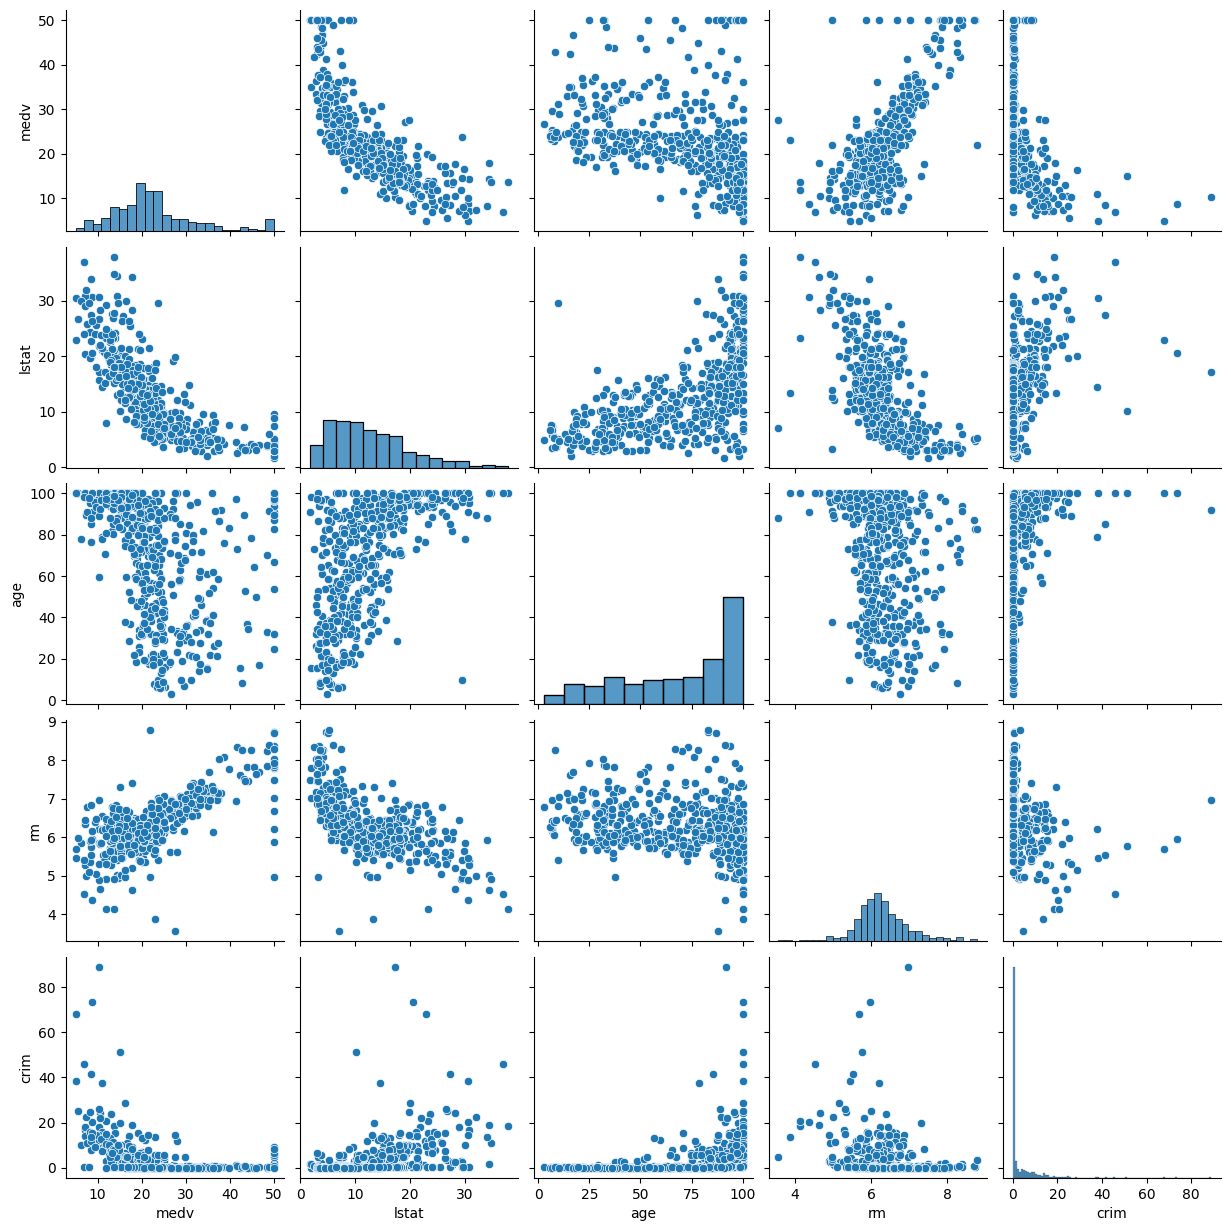

In [ ]:
p = sns.pairplot(df[['medv','lstat','age','rm','crim']])

In [ ]:
corr = df.corr()
print(corr)

             crim        zn     indus      chas       nox        rm       age  \
crim     1.000000 -0.200469  0.406583 -0.055892  0.420972 -0.219247  0.352734   
zn      -0.200469  1.000000 -0.533828 -0.042697 -0.516604  0.311991 -0.569537   
indus    0.406583 -0.533828  1.000000  0.062938  0.763651 -0.391676  0.644779   
chas    -0.055892 -0.042697  0.062938  1.000000  0.091203  0.091251  0.086518   
nox      0.420972 -0.516604  0.763651  0.091203  1.000000 -0.302188  0.731470   
rm      -0.219247  0.311991 -0.391676  0.091251 -0.302188  1.000000 -0.240265   
age      0.352734 -0.569537  0.644779  0.086518  0.731470 -0.240265  1.000000   
dis     -0.379670  0.664408 -0.708027 -0.099176 -0.769230  0.205246 -0.747881   
rad      0.625505 -0.311948  0.595129 -0.007368  0.611441 -0.209847  0.456022   
tax      0.582764 -0.314563  0.720760 -0.035587  0.668023 -0.292048  0.506456   
ptratio  0.289946 -0.391679  0.383248 -0.121515  0.188933 -0.355501  0.261515   
b       -0.385064  0.175520 

In [ ]:
print (df.corr().abs().nlargest(3,'medv').index)

Index(['medv', 'lstat', 'rm'], dtype='object')


In [ ]:
print(df.corr().abs().nlargest(3,'medv').values[:,13])

[1.         0.73766273 0.69535995]


In [ ]:
# This shows the correlation of everything compared to the Price (medv)
# and sorts them from highest to lowest.
print(df.corr()['medv'].sort_values(ascending=False))

medv       1.000000
rm         0.695360
zn         0.360445
b          0.333461
dis        0.249929
chas       0.175260
age       -0.376955
rad       -0.381626
crim      -0.388305
nox       -0.427321
tax       -0.468536
indus     -0.483725
ptratio   -0.507787
lstat     -0.737663
Name: medv, dtype: float64


In [ ]:
df[['medv','lstat']].corr()

In [ ]:
plt.scatter(df['lstat'],df['medv'],marker= 'o')
plt.xlabel('lstat')
plt.ylabel('medv')

In [ ]:
plt.scatter(df['rm'],df['medv'], marker ='o')
plt.xlabel('rm')
plt.ylabel('medv')

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(18,15))
ax = fig.add_subplot(111, projection ='3d')
ax.scatter(df['lstat'],
df['rm'],df['medv'],c='b')
ax.set_xlabel('lstat')
ax.set_ylabel('rm')
ax.set_zlabel('medv')
plt.show()

In [ ]:
import numpy as np

x = pd.DataFrame(np.c_[df["lstat"], df['rm']], columns = ['lstat' , 'rm'])
Y = df['medv']


from sklearn.model_selection import train_test_split
x_train, x_test, Y_train, Y_test = train_test_split(x,Y,test_size=0.3, random_state=5)

In [ ]:
print(x_train.shape)
print(Y_train.shape)

In [ ]:
x_train.head()


In [ ]:
Y_train.head()

In [ ]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train, Y_train)

In [ ]:
price_pred = model.predict(x_test)

result = np.column_stack((Y_test,price_pred))

In [ ]:
price_pred = model.predict(x_test)
r_2 = model.score(x_test, Y_test)
mse = mean_squared_error(Y_test, price_pred)
mae = mean_absolute_error(Y_test,price_pred)


print(r_2)
print(mse)
print(mae)


In [ ]:
from sklearn.metrics import mean_squared_error

plt.scatter(Y_test, price_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual prices vs Predicted prices")

In [ ]:
print(model.intercept_)
print(model.coef_)

In [ ]:
import warnings; warnings.simplefilter('ignore')
print(model.predict([[30,5]]))